# Hands-on Session: Satellite Imagery and Data for Urban Aerosol Analysis  
# Sesion praktik: Pamje dhe të dhëna satelitore për analizën e aerosoleve urbane

**Duration / Kohëzgjatja:** 1.5 hours / 1.5 orë  
**Level / Niveli:** advanced undergraduate, MSc, PhD, early-stage researchers / studentë të avancuar bachelor, master, doktoraturë dhe kërkues të rinj  
**Theme / Tema:** from radiation physics to satellite-like aerosol maps, spectral interpretation, and validation / nga fizika e rrezatimit te hartat satelitore të aerosoleve, interpretimi spektral dhe validimi.

---

### What this notebook does / Çfarë bën ky notebook

**EN.** This notebook is designed as a complete 90-minute teaching activity. It uses a self-contained, satellite-like urban aerosol dataset so that the session can run even without internet access. The workflow follows the logic: physical principle → aerosol optical depth retrieval → spectral interpretation → urban map analysis → validation with ground observations.

**SQ.** Ky notebook është projektuar si aktivitet i plotë 90-minutësh. Ai përdor një grup të dhënash të simuluara, por realiste, me karakteristika të ngjashme me produktet satelitore, në mënyrë që sesioni të zhvillohet edhe pa internet. Rrjedha e punës është: parimi fizik → përftimi i AOD → interpretimi spektral → analiza e hartës urbane → validimi me vrojtime tokësore.

> **Important / E rëndësishme:** The synthetic data are pedagogical. The same code structure can be adapted to real MODIS/VIIRS/Sentinel-5P/Giovanni/AERONET files.

## 0. Session plan / Plani i sesionit

| Time / Koha | Activity / Aktiviteti | Main output / Rezultati kryesor |
|---:|---|---|
| 0-10 min | Context, imports, data logic / Konteksti, bibliotekat, logjika e të dhënave | Notebook ready / Notebook gati |
| 10-25 min | Beer-Lambert-Bougier and optical depth / Ligji Beer-Lambert-Bougier dhe thellësia optike | Estimate τ from intensity / Vlerësimi i τ nga intensiteti |
| 25-40 min | AOD and Ångström exponent / AOD dhe eksponenti i Ångström-it | Particle-size interpretation / Interpretimi i madhësisë së grimcave |
| 40-65 min | Satellite-like urban AOD map / Hartë urbane AOD me logjikë satelitore | AOD and α maps / Harta AOD dhe α |
| 65-80 min | Ground validation / Validimi me stacion tokësor | Bias, RMSE, correlation / Bias, RMSE, korrelacion |
| 80-90 min | Mini-report / Mini-raport | Scientific interpretation / Interpretim shkencor |

### Learning outcomes / Rezultatet e të nxënit

After the session, participants should be able to / Pas sesionit, pjesëmarrësit duhet të jenë në gjendje të:

1. explain how atmospheric extinction leads to optical depth / shpjegojnë si shuarja atmosferike çon te thellësia optike;
2. compute AOD and Ångström exponent from multi-wavelength data / llogarisin AOD dhe eksponentin e Ångström-it nga të dhëna me shumë gjatësi vale;
3. interpret an urban aerosol map using AOD and spectral dependence / interpretojnë një hartë aerosoli urban duke përdorur AOD dhe varësinë spektrale;
4. validate satellite-like AOD against ground observations / validojnë AOD-in satelitor ndaj vrojtimeve tokësore;
5. write a short diagnosis of an aerosol event / shkruajnë një diagnozë të shkurtër të një ngjarjeje aerosoli.

In [20]:
# ============================================================
# 1. Python setup / Përgatitja e mjedisit Python
# ============================================================

%pip install contextily pyproj

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import contextily as ctx
from pyproj import Transformer

np.random.seed(42)

# Keep figures readable in a classroom / Figura të lexueshme për mësim
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUT = Path("outputs_urban_aerosol_session")
OUT.mkdir(exist_ok=True)

print("Ready. Output folder:", OUT.resolve())

Ready. Output folder: /content/outputs_urban_aerosol_session


## 1. Physical basis: attenuation and optical depth  
## 1. Baza fizike: zbehja e rrezatimit dhe thellësia optike

**EN.** Atmospheric aerosols scatter and absorb incoming solar radiation. In a simple direct-beam approximation, the transmitted intensity is described by the Beer-Lambert-Bougier law:

$$
I(\lambda) = I_0(\lambda) \exp[-\tau(\lambda)m],
$$

where:

- $I_0(\lambda)$ is the extraterrestrial or top-of-atmosphere intensity;
- $I(\lambda)$ is the measured intensity;
- $\tau(\lambda)$ is optical depth;
- $m$ is relative optical air mass.

**SQ.** Aerosolët atmosferikë shpërndajnë dhe absorbojnë rrezatimin diellor. Në një përafrim të thjeshtë të rrezes direkte, intensiteti i transmetuar përshkruhet nga ligji Beer-Lambert-Bougier:

$$
I(\lambda) = I_0(\lambda) \exp[-\tau(\lambda)m].
$$

Këtu:

- $I_0(\lambda)$ është intensiteti jashtë atmosferës ose në majë të atmosferës;
- $I(\lambda)$ është intensiteti i matur;
- $\tau(\lambda)$ është thellësia optike;
- $m$ është masa optike relative e ajrit.

For solar zenith angle $\theta$ in degrees, we use the Kasten-Young approximation:

$$
m = \frac{1}{\cos\theta + 0.50572(96.07995 - \theta)^{-1.6364}}.
$$

In [6]:
# ============================================================
# 2. Air mass and synthetic direct-beam measurements
#    Masa optike dhe matje sintetike të rrezes direkte
# ============================================================

def airmass_kasten_young(sza_deg):
    """
    Relative optical air mass from solar zenith angle.
    Masa optike relative nga këndi zenital diellor.
    Valid for sza_deg < about 90 degrees.
    """
    sza = np.asarray(sza_deg, dtype=float)
    return 1.0 / (np.cos(np.deg2rad(sza)) + 0.50572 * (96.07995 - sza) ** (-1.6364))

# Synthetic classroom measurements at one wavelength, e.g. 500 nm
# Matje sintetike për mësim në një gjatësi vale, p.sh. 500 nm
sza = np.array([20, 30, 40, 50, 60, 65, 70, 75], dtype=float)
m = airmass_kasten_young(sza)
I0_true = 1000.0  # W m^-2, illustrative / vlerë ilustruese
tau_true = 0.35   # moderate aerosol loading / ngarkesë mesatare aerosoli
noise = np.random.normal(0, 12, size=sza.size)
I_measured = I0_true * np.exp(-tau_true * m) + noise

langley_df = pd.DataFrame({
    "solar_zenith_angle_deg": sza,
    "air_mass_m": m,
    "measured_intensity_W_m2": I_measured
})
langley_df

,solar_zenith_angle_deg,air_mass_m,measured_intensity_W_m2
0,20.0,1.063700,676.996943
1,30.0,1.153992,671.483672
2,40.0,1.304224,622.614506
3,50.0,1.553407,563.652875
4,60.0,1.994293,515.166010
5,65.0,2.356019,435.698047
6,70.0,2.903147,362.813864
7,75.0,3.812912,246.187766


Estimated tau / τ e vlerësuar = 0.363
Estimated I0 / I0 i vlerësuar = 1014.0 W m^-2
True tau used to build the exercise / τ real i përdorur = 0.350


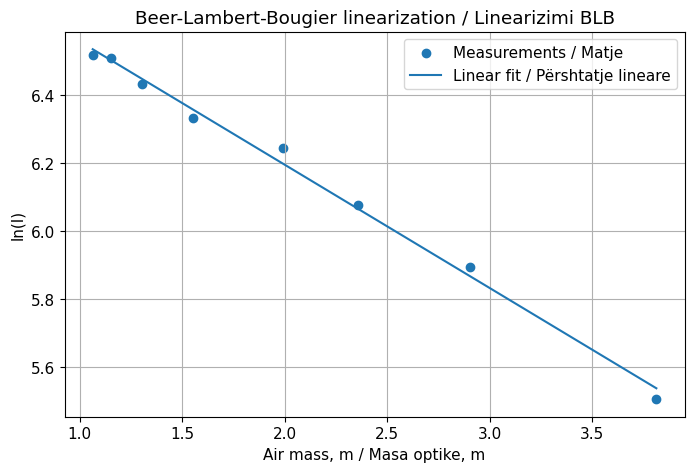

In [7]:
# ============================================================
# 3. Langley-style linear fit / Përshtatje lineare e tipit Langley
#    ln(I) = ln(I0) - tau*m
# ============================================================

x = langley_df["air_mass_m"].values
y = np.log(langley_df["measured_intensity_W_m2"].values)

slope, intercept = np.polyfit(x, y, deg=1)
tau_est = -slope
I0_est = np.exp(intercept)

print(f"Estimated tau / τ e vlerësuar = {tau_est:.3f}")
print(f"Estimated I0 / I0 i vlerësuar = {I0_est:.1f} W m^-2")
print(f"True tau used to build the exercise / τ real i përdorur = {tau_true:.3f}")

# Plot / Grafik
m_fit = np.linspace(x.min(), x.max(), 100)
lnI_fit = intercept + slope * m_fit

fig, ax = plt.subplots()
ax.scatter(x, y, label="Measurements / Matje")
ax.plot(m_fit, lnI_fit, label="Linear fit / Përshtatje lineare")
ax.set_xlabel("Air mass, m / Masa optike, m")
ax.set_ylabel("ln(I)")
ax.set_title("Beer-Lambert-Bougier linearization / Linearizimi BLB")
ax.legend()
plt.show()

### Short interpretation / Interpretim i shkurtër

**EN.** The slope of the line is $-\tau$. A larger optical depth means stronger attenuation: less direct radiation reaches the sensor or surface.

**SQ.** Pjerrësia e drejtëzës është $-\tau$. Sa më e madhe thellësia optike, aq më e fortë është shuarja e rrezatimit: më pak rrezatim direkt arrin në sensor ose në sipërfaqe.

### Student task 1 / Detyra 1 për studentët

Change `tau_true` above to 0.10, 0.60 and 1.20. Re-run the cells and answer:

Ndryshoni `tau_true` më sipër në 0.10, 0.60 dhe 1.20. Riekzekutoni qelizat dhe përgjigjuni:

1. How does the slope change? / Si ndryshon pjerrësia?
2. What happens to the measured intensity for large air mass? / Çfarë ndodh me intensitetin e matur për masa optike të mëdha?
3. Which case corresponds to clean, moderate, and very hazy atmosphere? / Cili rast i përket atmosferës së pastër, mesatare dhe shumë të ndotur?

## 2. Aerosol Optical Depth and Ångström exponent  
## 2. Thellësia optike e aerosoleve dhe eksponenti i Ångström-it

**EN.** Aerosol Optical Depth, AOD, is the aerosol contribution to total optical depth. Multi-wavelength AOD carries information about particle size. The Ångström law is:

$$
AOD(\lambda) = \beta \lambda^{-\alpha},
$$

or in logarithmic form:

$$
\ln[AOD(\lambda)] = \ln\beta - \alpha \ln\lambda.
$$

A useful two-wavelength estimate is:

$$
\alpha = -\frac{\ln(AOD_1/AOD_2)}{\ln(\lambda_1/\lambda_2)}.
$$

**SQ.** Thellësia optike e aerosoleve, AOD, është kontributi i aerosoleve në thellësinë optike totale. AOD-i në disa gjatësi vale jep informacion mbi madhësinë e grimcave. Ligji i Ångström-it është:

$$
AOD(\lambda) = \beta \lambda^{-\alpha}.
$$

Në formë logaritmike:

$$
\ln[AOD(\lambda)] = \ln\beta - \alpha \ln\lambda.
$$

Një vlerësim me dy gjatësi vale është:

$$
\alpha = -\frac{\ln(AOD_1/AOD_2)}{\ln(\lambda_1/\lambda_2)}.
$$

In [8]:
# ============================================================
# 4. Ångström exponent functions / Funksione për eksponentin Ångström
# ============================================================

def angstrom_exponent(lambda1_nm, aod1, lambda2_nm, aod2):
    """Compute Ångström exponent from two AOD measurements."""
    return -np.log(aod1 / aod2) / np.log(lambda1_nm / lambda2_nm)

def fit_angstrom(wavelength_nm, aod):
    """
    Fit ln(AOD) = ln(beta) - alpha ln(lambda).
    Returns alpha, beta, fitted AOD values.
    """
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    aod = np.asarray(aod, dtype=float)
    slope, intercept = np.polyfit(np.log(wavelength_nm), np.log(aod), deg=1)
    alpha = -slope
    beta = np.exp(intercept)
    aod_fit = beta * wavelength_nm ** (-alpha)
    return alpha, beta, aod_fit

# Example over an urban-industrial region / Shembull mbi një rajon urbano-industrial
wavelengths = np.array([440, 550, 870], dtype=float)
aod_values = np.array([0.62, 0.48, 0.20], dtype=float)

alpha_440_870 = angstrom_exponent(440, 0.62, 870, 0.20)
alpha_fit, beta_fit, aod_fit = fit_angstrom(wavelengths, aod_values)

print(f"Two-wavelength alpha 440-870 nm / α me dy gjatësi vale = {alpha_440_870:.2f}")
print(f"Three-wavelength fitted alpha / α nga përshtatja = {alpha_fit:.2f}")
print(f"Turbidity coefficient beta / Koeficienti β = {beta_fit:.2e}")

pd.DataFrame({"wavelength_nm": wavelengths, "AOD": aod_values, "AOD_fit": aod_fit})

Two-wavelength alpha 440-870 nm / α me dy gjatësi vale = 1.66
Three-wavelength fitted alpha / α nga përshtatja = 1.70
Turbidity coefficient beta / Koeficienti β = 1.99e+04


,wavelength_nm,AOD,AOD_fit
0,440.0,0.62,0.651360
1,550.0,0.48,0.446051
2,870.0,0.20,0.204860


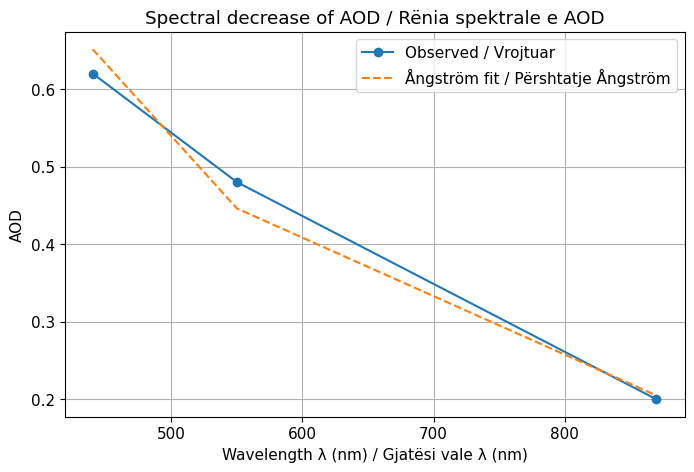

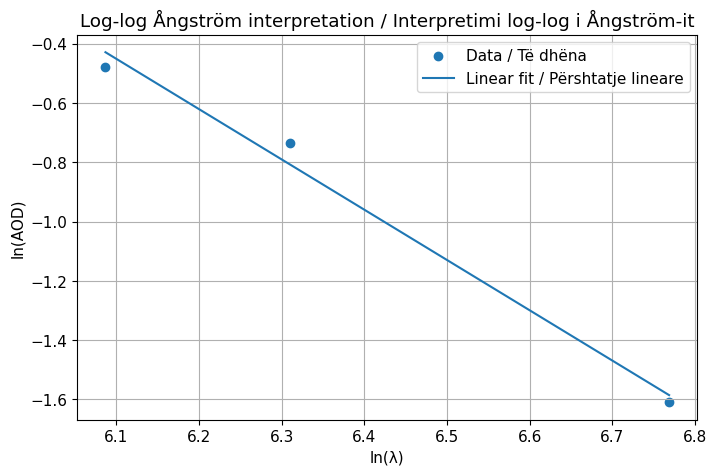

In [9]:
# Plot spectral behavior / Paraqitja e sjelljes spektrale
fig, ax = plt.subplots()
ax.plot(wavelengths, aod_values, "o-", label="Observed / Vrojtuar")
ax.plot(wavelengths, aod_fit, "--", label="Ångström fit / Përshtatje Ångström")
ax.set_xlabel("Wavelength λ (nm) / Gjatësi vale λ (nm)")
ax.set_ylabel("AOD")
ax.set_title("Spectral decrease of AOD / Rënia spektrale e AOD")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(np.log(wavelengths), np.log(aod_values), label="Data / Të dhëna")
ax.plot(np.log(wavelengths), np.log(aod_fit), label="Linear fit / Përshtatje lineare")
ax.set_xlabel("ln(λ)")
ax.set_ylabel("ln(AOD)")
ax.set_title("Log-log Ångström interpretation / Interpretimi log-log i Ångström-it")
ax.legend()
plt.show()

### Aerosol interpretation table / Tabelë interpretimi për aerosolët

| Ångström exponent α | Interpretation EN | Interpretimi SQ |
|---:|---|---|
| α < 0.2 | very coarse particles; dust or sea salt | grimca shumë të mëdha; pluhur ose kripë detare |
| 0.2-1.0 | mixed coarse + fine particles | përzierje grimcash të mëdha dhe të imta |
| 1.0-1.5 | fine-mode contribution is important; urban/industrial | kontribut i rëndësishëm i grimcave të imta; urbano-industriale |
| 1.3-2.0 | fine particles dominate; smoke/biomass burning | dominojnë grimcat e imta; tym/djegie biomase |
| > 2.0 | very fine particles; secondary sulfate/nitrate/organic aerosol | grimca shumë të imta; sulfate/nitrate/organike sekondare |

### Student task 2 / Detyra 2 për studentët

Use the example values below and compute α manually or with the function:

Përdorni vlerat më poshtë dhe llogaritni α me dorë ose me funksionin:

| λ (nm) | AOD |
|---:|---:|
| 500 | 0.30 |
| 1000 | 0.12 |

Questions / Pyetje:

1. Is α large or small? / A është α i madh apo i vogël?
2. Do fine or coarse particles dominate? / Dominojnë grimcat e imta apo të mëdha?
3. Which source is more plausible in a city: dust, traffic/industry, or sea salt? / Cili burim është më i mundshëm në qytet: pluhur, trafik/industri apo kripë detare?

In [10]:
# Student task 2 workspace / Hapësirë pune për detyrën 2
lambda_a = 500
lambda_b = 1000
aod_a = 0.30
aod_b = 0.12

alpha_task2 = angstrom_exponent(lambda_a, aod_a, lambda_b, aod_b)
print(f"α = {alpha_task2:.2f}")

α = 1.32


## 3. Satellite-like urban aerosol scene  
## 3. Skenë urbane aerosoli përmes satelitëve

**EN.** Satellite products such as MODIS, VIIRS, Sentinel-5P/TROPOMI, MISR, CALIOP/CALIPSO and geostationary imagers provide complementary aerosol information. For a hands-on class, we will create a small satellite-like grid centered near Tirana, Albania. The scene includes:

- a regional background AOD;
- an urban-industrial fine-mode plume;
- a weaker transported coarse-mode dust contribution;
- missing pixels representing cloud screening.

**SQ.** Produkte satelitore si MODIS, VIIRS, Sentinel-5P/TROPOMI, MISR, CALIOP/CALIPSO dhe satelitët gjeostacionarë japin informacione plotësuese për aerosolët. Për këtë ushtrim do të krijojmë një rrjetë të vogël me logjikë satelitore, të qendërzuar pranë Tiranës. Skena përmban:

- AOD rajonal bazë;
- një shtëllungë urbane-industriale me grimca të imta;
- një kontribut më të dobët të pluhurit të transportuar me grimca të mëdha;
- pikselë të munguar që përfaqësojnë filtrimin nga retë.

In [23]:
# ============================================================
# 5. Create a satellite-like AOD grid / Krijimi i rrjetës së tipit satelitor
# ============================================================

# ============================================================
# 5. Create a satellite-like AOD grid over Tirana
#    Krijimi i rrjetës satelitore AOD mbi Tiranë
# ============================================================

# For reproducibility / Për riprodhueshmëri
np.random.seed(42)

# Approximate Tirana coordinates for the pedagogical example
# Koordinata të përafërta të Tiranës për shembull pedagogjik
lat0, lon0 = 41.3275, 19.8187

# Create latitude-longitude grid around Tirana
# Krijojmë rrjetën gjerësi-gjatësi gjeografike rreth Tiranës
nlat, nlon = 90, 90
lat = np.linspace(lat0 - 0.45, lat0 + 0.45, nlat)
lon = np.linspace(lon0 - 0.55, lon0 + 0.55, nlon)
LON, LAT = np.meshgrid(lon, lat)

# Distance-like coordinates in degrees, sufficient for classroom map visualization
# Koordinata relative në gradë, të mjaftueshme për vizualizim mësimor
x = LON - lon0
y = LAT - lat0

# ------------------------------------------------------------
# Synthetic aerosol sources
# Burime sintetike aerosoli
# ------------------------------------------------------------

# Urban source centered on the city
# Burim urban në qendër të qytetit
urban_plume = np.exp(-((x / 0.18)**2 + (y / 0.12)**2))

# Industrial source southeast of city with a NE transport direction
# Burim industrial në juglindje me transport drejt verilindjes
industrial_lon = lon0 + 0.18
industrial_lat = lat0 - 0.12

x_ind = LON - industrial_lon
y_ind = LAT - industrial_lat

industrial_plume = np.exp(
    -((x_ind - 0.35 * y_ind) / 0.16)**2
    - (y_ind / 0.18)**2
)

# Coarse dust tongue from southwest
# Gjuhë pluhuri me grimca të mëdha nga jugperëndimi
x_dust = LON - (lon0 - 0.25)
y_dust = LAT - (lat0 - 0.25)

dust_tongue = np.exp(
    -((x_dust + 0.55 * y_dust) / 0.35)**2
    - (y_dust / 0.25)**2
)

# ------------------------------------------------------------
# AOD and Ångström exponent fields
# Fushat AOD dhe të eksponentit të Ångström-it
# ------------------------------------------------------------

# AOD at 550 nm: background + urban + industrial + dust
# AOD në 550 nm: sfond + urban + industrial + pluhur
AOD550 = (
    0.12
    + 0.30 * urban_plume
    + 0.22 * industrial_plume
    + 0.16 * dust_tongue
)

AOD550 += np.random.normal(0, 0.012, size=AOD550.shape)
AOD550 = np.clip(AOD550, 0.03, None)

# Ångström exponent map: high for fine urban particles, lower for coarse dust
# Harta e eksponentit Ångström: vlera të larta për grimca të imta urbane,
# vlera më të ulëta për pluhur të trashë
alpha_map = (
    0.85
    + 0.95 * urban_plume
    + 0.70 * industrial_plume
    - 0.55 * dust_tongue
)

alpha_map += np.random.normal(0, 0.08, size=alpha_map.shape)
alpha_map = np.clip(alpha_map, 0.05, 2.5)

# Generate AOD at other wavelengths using Ångström law relative to 550 nm
# Gjenerojmë AOD në gjatësi të tjera vale duke përdorur ligjin e Ångström-it ndaj 550 nm
AOD440 = AOD550 * (440 / 550) ** (-alpha_map)
AOD870 = AOD550 * (870 / 550) ** (-alpha_map)

# ------------------------------------------------------------
# Cloud or missing-pixel mask
# Maskë resh ose pikselë të munguar
# ------------------------------------------------------------

cloud_score = (
    np.sin(12 * x)
    + np.cos(10 * y)
    + np.random.normal(0, 0.9, size=AOD550.shape)
)

cloud_mask = cloud_score > 2.15

AOD550_masked = AOD550.copy()
AOD440_masked = AOD440.copy()
AOD870_masked = AOD870.copy()
alpha_masked = alpha_map.copy()

AOD550_masked[cloud_mask] = np.nan
AOD440_masked[cloud_mask] = np.nan
AOD870_masked[cloud_mask] = np.nan
alpha_masked[cloud_mask] = np.nan

# Geographic extent in longitude-latitude
# Shtrirja gjeografike në gjatësi-gjerësi gjeografike
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ------------------------------------------------------------
# Project Tirana grid from lon/lat to Web Mercator
# Projektojmë rrjetën e Tiranës nga lon/lat në Web Mercator
# ------------------------------------------------------------

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

X_WEB, Y_WEB = transformer.transform(LON, LAT)

tirana_x, tirana_y = transformer.transform(lon0, lat0)
industrial_x, industrial_y = transformer.transform(industrial_lon, industrial_lat)

extent_3857 = [
    np.nanmin(X_WEB),
    np.nanmax(X_WEB),
    np.nanmin(Y_WEB),
    np.nanmax(Y_WEB)
]

# ------------------------------------------------------------
# Quick diagnostics
# Kontroll i shpejtë
# ------------------------------------------------------------

print("Grid shape / Përmasa e rrjetës:", AOD550.shape)
print("Missing pixels / Pikselë të munguar:", np.isnan(AOD550_masked).mean().round(3))
print("Longitude range / Intervali i gjatësisë gjeografike:", lon.min().round(3), lon.max().round(3))
print("Latitude range / Intervali i gjerësisë gjeografike:", lat.min().round(3), lat.max().round(3))

Grid shape / Përmasa e rrjetës: (90, 90)
Missing pixels / Pikselë të munguar: 0.041
Longitude range / Intervali i gjatësisë gjeografike: 19.269 20.369
Latitude range / Intervali i gjerësisë gjeografike: 40.878 41.778


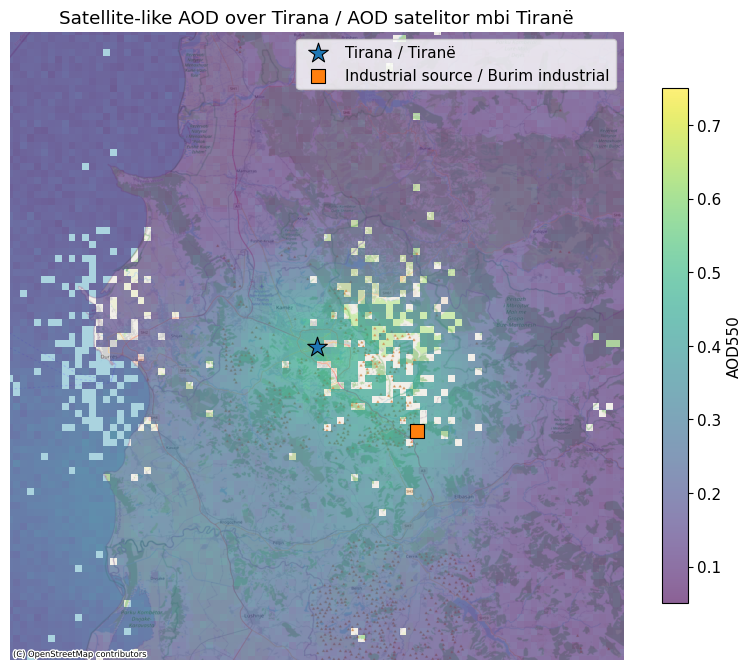

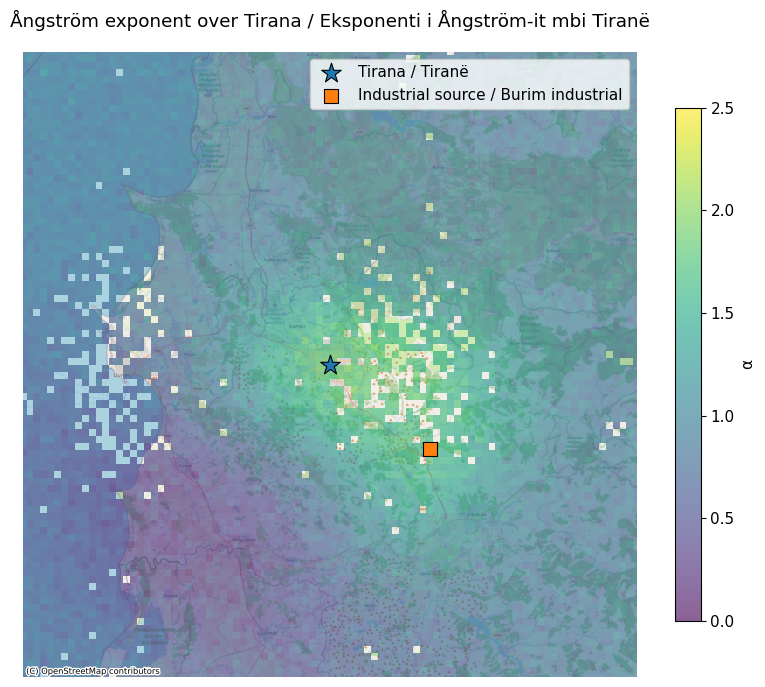

In [24]:
# ============================================================
# 6. Plot AOD and alpha maps / Paraqitja e hartave AOD dhe alpha
# ============================================================

def plot_map_on_tirana(data, title, cbar_label, vmin=None, vmax=None, alpha=0.65):
    fig, ax = plt.subplots(figsize=(8, 7))

    # Set map limits first / Vendosim kufijtë e hartës
    ax.set_xlim(extent_3857[0], extent_3857[1])
    ax.set_ylim(extent_3857[2], extent_3857[3])

    # Add Tirana basemap / Shtojmë hartën bazë të Tiranës
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom=11,
        attribution_size=6
    )

    # Overlay aerosol field / Mbivendosim fushën e aerosoleve
    im = ax.pcolormesh(
        X_WEB,
        Y_WEB,
        data,
        shading="auto",
        alpha=alpha,
        vmin=vmin,
        vmax=vmax
    )

    # Mark Tirana and the synthetic industrial source
    # Shënojmë Tiranën dhe burimin industrial sintetik
    ax.scatter(
        [tirana_x], [tirana_y],
        marker="*",
        s=220,
        edgecolor="black",
        linewidth=0.8,
        label="Tirana / Tiranë"
    )

    ax.scatter(
        [industrial_x], [industrial_y],
        marker="s",
        s=90,
        edgecolor="black",
        linewidth=0.8,
        label="Industrial source / Burim industrial"
    )

    ax.set_title(title)
    ax.set_axis_off()
    ax.legend(loc="upper right")

    cbar = plt.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()

plot_map_on_tirana(
    AOD550_masked,
    "Satellite-like AOD over Tirana / AOD satelitor mbi Tiranë",
    "AOD550",
    vmin=0.05,
    vmax=0.75,
    alpha=0.62
)

plot_map_on_tirana(
    alpha_masked,
    "Ångström exponent over Tirana / Eksponenti i Ångström-it mbi Tiranë",
    "α",
    vmin=0.0,
    vmax=2.5,
    alpha=0.62
)

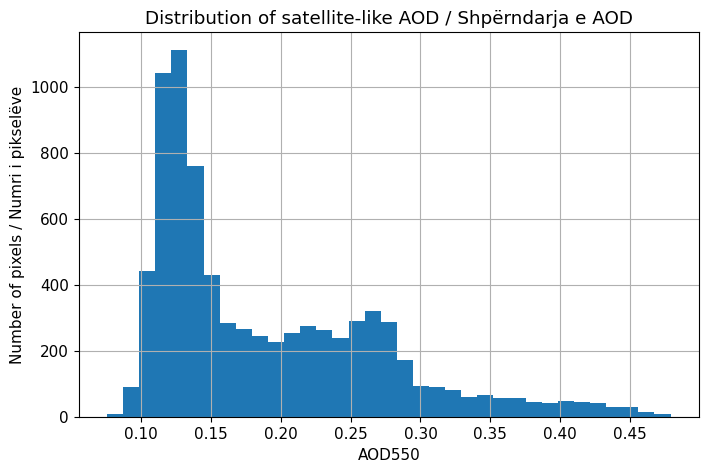

Urban mean AOD550 / AOD mesatar urban = 0.372
Rural mean AOD550 / AOD mesatar rural = 0.156
Urban-rural difference / Diferenca urban-rural = 0.215


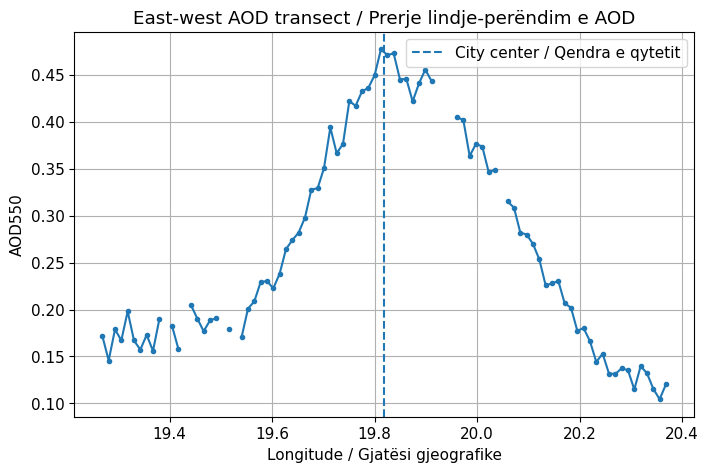

In [13]:
# ============================================================
# 7. AOD histogram and urban-rural contrast
#    Histogrami AOD dhe kontrasti urban-rural
# ============================================================

valid = np.isfinite(AOD550_masked)

fig, ax = plt.subplots()
ax.hist(AOD550_masked[valid].ravel(), bins=35)
ax.set_xlabel("AOD550")
ax.set_ylabel("Number of pixels / Numri i pikselëve")
ax.set_title("Distribution of satellite-like AOD / Shpërndarja e AOD")
plt.show()

# Define simple urban and rural masks / Maska të thjeshta urbane dhe rurale
r_city = np.sqrt(((LON - lon0)/0.16)**2 + ((LAT - lat0)/0.12)**2)
urban_mask = (r_city < 1.0) & valid
rural_mask = (r_city > 2.6) & valid

urban_mean = np.nanmean(AOD550_masked[urban_mask])
rural_mean = np.nanmean(AOD550_masked[rural_mask])
print(f"Urban mean AOD550 / AOD mesatar urban = {urban_mean:.3f}")
print(f"Rural mean AOD550 / AOD mesatar rural = {rural_mean:.3f}")
print(f"Urban-rural difference / Diferenca urban-rural = {urban_mean - rural_mean:.3f}")

# East-west transect through city / Prerje lindje-perëndim përmes qytetit
row_city = np.argmin(np.abs(lat - lat0))
fig, ax = plt.subplots()
ax.plot(lon, AOD550_masked[row_city, :], marker="o", ms=3)
ax.axvline(lon0, linestyle="--", label="City center / Qendra e qytetit")
ax.set_xlabel("Longitude / Gjatësi gjeografike")
ax.set_ylabel("AOD550")
ax.set_title("East-west AOD transect / Prerje lindje-perëndim e AOD")
ax.legend()
plt.show()

### Student task 3 / Detyra 3 për studentët

**EN.** Inspect the AOD map and the α map together. Answer:

1. Where is the strongest aerosol loading?
2. Does the highest AOD correspond to fine particles, coarse particles, or a mixture?
3. Is the industrial source distinguishable from the city-center plume?
4. How do missing pixels affect your interpretation?

**SQ.** Vëzhgoni së bashku hartën AOD dhe hartën α. Përgjigjuni:

1. Ku është ngarkesa më e fortë e aerosoleve?
2. A përkon AOD-i më i lartë me grimca të imta, të mëdha apo me përzierje?
3. A dallohet burimi industrial nga penda e qendrës urbane?
4. Si ndikojnë pikselët e munguar në interpretim?

In [14]:
# ============================================================
# 8. Simple aerosol classification from AOD and alpha
#    Klasifikim i thjeshtë i aerosoleve nga AOD dhe alpha
# ============================================================

classification = np.full(AOD550.shape, "missing", dtype=object)
classification[(alpha_map < 0.7) & valid] = "coarse / dust-like"
classification[(alpha_map >= 0.7) & (alpha_map < 1.3) & valid] = "mixed"
classification[(alpha_map >= 1.3) & (alpha_map < 1.8) & valid] = "fine urban/industrial"
classification[(alpha_map >= 1.8) & valid] = "very fine / secondary"

class_order = ["coarse / dust-like", "mixed", "fine urban/industrial", "very fine / secondary", "missing"]
class_counts = pd.Series(classification.ravel()).value_counts().reindex(class_order).fillna(0).astype(int)
class_counts

,count
coarse / dust-like,1830
mixed,5352
fine urban/industrial,581
very fine / secondary,49
missing,288


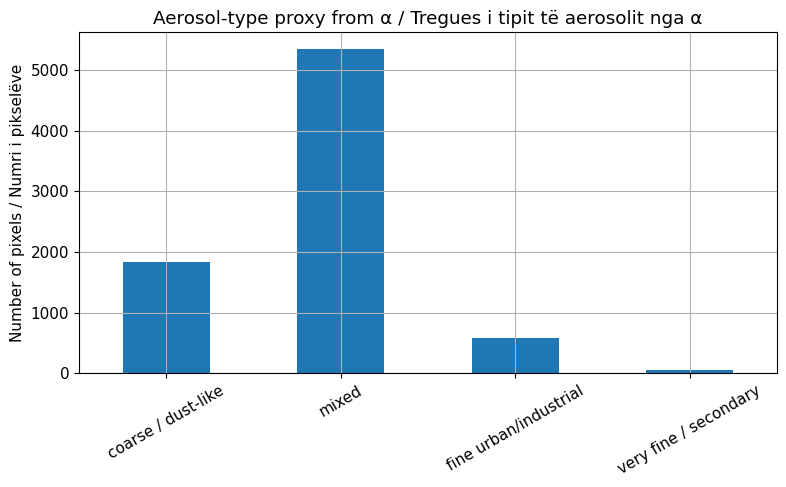

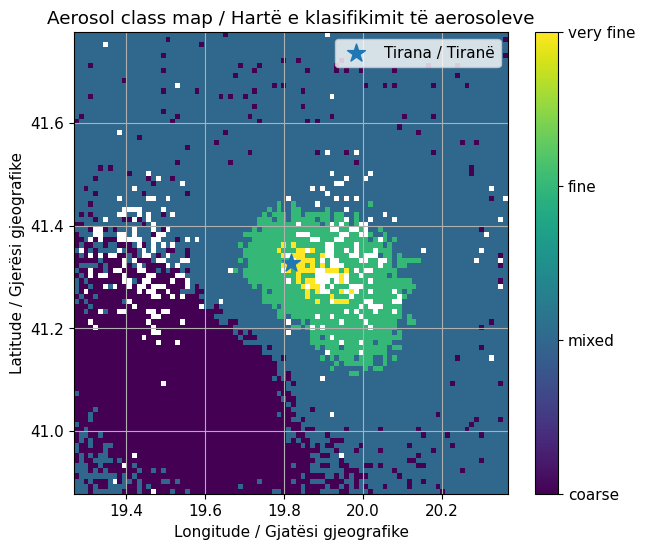

In [15]:
# Plot the class counts / Paraqitja e numrit të pikselëve për klasë
fig, ax = plt.subplots()
class_counts.drop("missing").plot(kind="bar", ax=ax)
ax.set_ylabel("Number of pixels / Numri i pikselëve")
ax.set_title("Aerosol-type proxy from α / Tregues i tipit të aerosolit nga α")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Make a numerical map for visualization / Hartë numerike për vizualizim
class_to_int = {
    "coarse / dust-like": 0,
    "mixed": 1,
    "fine urban/industrial": 2,
    "very fine / secondary": 3,
    "missing": np.nan,
}
class_map = np.vectorize(class_to_int.get, otypes=[float])(classification)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(class_map, origin="lower", extent=extent, aspect="auto", vmin=0, vmax=3)
ax.scatter([lon0], [lat0], marker="*", s=180, label="Tirana / Tiranë")
ax.set_xlabel("Longitude / Gjatësi gjeografike")
ax.set_ylabel("Latitude / Gjerësi gjeografike")
ax.set_title("Aerosol class map / Hartë e klasifikimit të aerosoleve")
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["coarse", "mixed", "fine", "very fine"])
ax.legend()
plt.show()

## 4. Validation: compare satellite-like AOD with ground observations  
## 4. Validimi: krahasimi i AOD-it satelitor me vrojtimet tokësore

**EN.** Satellite aerosol products are commonly validated against ground networks such as AERONET. A practical match-up requires spatial and temporal co-location, for example a radius of about 15-25 km and a time window of about ±30 minutes. Here we use synthetic AERONET-like observations at the city center.

**SQ.** Produktet satelitore të aerosoleve zakonisht validohen ndaj rrjeteve tokësore si AERONET. Një krahasim praktik kërkon bashkëvendosje hapësinore dhe kohore, për shembull rreze rreth 15-25 km dhe dritare kohore rreth ±30 minuta. Këtu përdorim vrojtime sintetike të tipit AERONET në qendër të qytetit.

In [16]:
# ============================================================
# 9. Validation dataset / Grup të dhënash për validim
# ============================================================

# Build an illustrative 10-day time series with one satellite overpass per day.
# Ndërtojmë një seri 10-ditore me një kalim satelitor në ditë.
dates = pd.date_range("2026-06-01", periods=10, freq="D")

# AERONET-like AOD500 and alpha: background + event peak around day 5
# AOD500 dhe alpha të tipit AERONET: sfond + kulm ngjarjeje rreth ditës 5
peak = np.exp(-0.5*((np.arange(len(dates)) - 5)/1.5)**2)
aeronet_aod500 = 0.14 + 0.42*peak + np.random.normal(0, 0.015, len(dates))
aeronet_alpha = 1.15 + 0.55*peak + np.random.normal(0, 0.08, len(dates))

# Satellite-like AOD550 with small negative bias and random error.
# AOD550 satelitor me bias të vogël negativ dhe gabim rastësor.
sat_aod550 = 0.93*aeronet_aod500 + np.random.normal(0, 0.035, len(dates))
sat_aod550 = np.clip(sat_aod550, 0.02, None)

validation_df = pd.DataFrame({
    "date": dates,
    "AERONET_like_AOD500": aeronet_aod500,
    "AERONET_like_alpha": aeronet_alpha,
    "Satellite_like_AOD550": sat_aod550,
})
validation_df

,date,AERONET_like_AOD500,AERONET_like_alpha,Satellite_like_AOD550
0,2026-06-01,0.149731,1.116821,0.131117
1,2026-06-02,0.136254,1.240069,0.141787
2,2026-06-03,0.160401,1.253315,0.114984
3,2026-06-04,0.310266,1.401325,0.295298
4,2026-06-05,0.480177,1.540476,0.424131
5,2026-06-06,0.558274,1.574854,0.465355
6,2026-06-07,0.519316,1.550295,0.477184
7,2026-06-08,0.318350,1.398722,0.349837
8,2026-06-09,0.199048,1.188858,0.134064
9,2026-06-10,0.158441,1.189049,0.151529


Bias satellite-ground / Bias satelit-tokë = -0.030
RMSE = 0.046
Correlation r / Korrelacioni r = 0.977


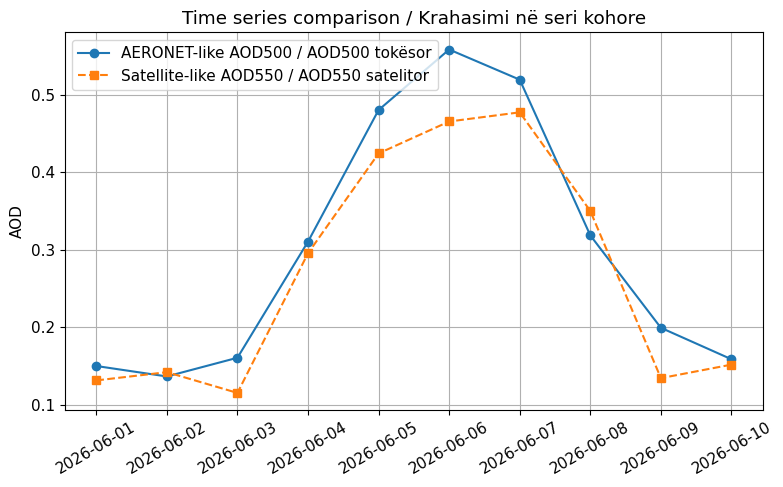

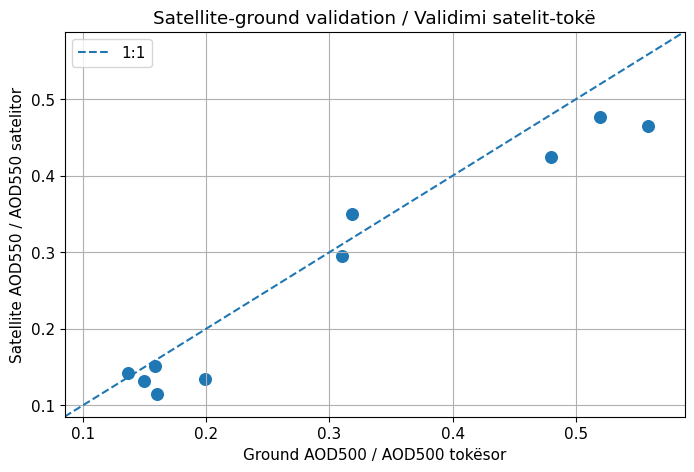

In [17]:
# ============================================================
# 10. Validation statistics / Statistikat e validimit
# ============================================================

x_obs = validation_df["AERONET_like_AOD500"].values
y_sat = validation_df["Satellite_like_AOD550"].values

bias = np.mean(y_sat - x_obs)
rmse = np.sqrt(np.mean((y_sat - x_obs)**2))
r = np.corrcoef(x_obs, y_sat)[0, 1]

print(f"Bias satellite-ground / Bias satelit-tokë = {bias:+.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"Correlation r / Korrelacioni r = {r:.3f}")

# Time series plot / Seritë kohore
fig, ax = plt.subplots()
ax.plot(validation_df["date"], x_obs, "o-", label="AERONET-like AOD500 / AOD500 tokësor")
ax.plot(validation_df["date"], y_sat, "s--", label="Satellite-like AOD550 / AOD550 satelitor")
ax.set_ylabel("AOD")
ax.set_title("Time series comparison / Krahasimi në seri kohore")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Scatter plot / Grafik shpërndarjeje
fig, ax = plt.subplots()
ax.scatter(x_obs, y_sat, s=70)
lims = [min(x_obs.min(), y_sat.min()) - 0.03, max(x_obs.max(), y_sat.max()) + 0.03]
ax.plot(lims, lims, "--", label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Ground AOD500 / AOD500 tokësor")
ax.set_ylabel("Satellite AOD550 / AOD550 satelitor")
ax.set_title("Satellite-ground validation / Validimi satelit-tokë")
ax.legend()
plt.show()

### Student task 4 / Detyra 4 për studentët

**EN.** The satellite-like product has a small bias and random uncertainty. Discuss:

1. Is the satellite product overestimating or underestimating the ground observations?
2. Which statistic is most useful for systematic error: bias, RMSE, or correlation?
3. Why should we not expect perfect agreement between AOD500 and AOD550?
4. What could happen if the satellite pixel is partly cloudy or if the surface is very bright?

**SQ.** Produkti satelitor i simuluar ka një bias të vogël dhe pasiguri rastësore. Diskutoni:

1. A po i mbivlerëson apo nënvlerëson produkti satelitor vrojtimet tokësore?
2. Cila statistikë është më e dobishme për gabimin sistematik: bias, RMSE apo korrelacioni?
3. Pse nuk presim përputhje perfekte midis AOD500 dhe AOD550?
4. Çfarë mund të ndodhë nëse pikseli satelitor është pjesërisht me re ose nëse sipërfaqja është shumë e ndritshme?

## 5. Optional real-data workflow / Rrjedhë pune opsionale me të dhëna reale

**EN.** If internet access and downloaded files are available, participants can repeat the same workflow with real products. The recommended practical sequence is:

1. Open **NASA Worldview** and identify a dust, smoke, or urban haze event over the region of interest.
2. Use **Giovanni** to download MODIS or VIIRS AOD over a box around the city.
3. Download **AERONET** AOD(500 nm) and Ångström exponent for the nearest station.
4. Compare the satellite time series with AERONET using the validation functions above.
5. Optionally compare with **CAMS** aerosol species or a **HYSPLIT** back-trajectory.

**SQ.** Nëse ka internet dhe skedarë të shkarkuar, pjesëmarrësit mund ta përsërisin rrjedhën e punës me produkte reale. Sekuenca e rekomanduar është:

1. Hapni **NASA Worldview** dhe identifikoni një ngjarje pluhuri, tymi ose smogu urban mbi rajonin e interesit.
2. Përdorni **Giovanni** për të shkarkuar AOD nga MODIS ose VIIRS mbi një kuti rreth qytetit.
3. Shkarkoni nga **AERONET** AOD(500 nm) dhe eksponentin e Ångström-it për stacionin më të afërt.
4. Krahasoni serinë kohore satelitore me AERONET duke përdorur funksionet e validimit më sipër.
5. Opsionalisht, krahasoni me speciet aerosole të **CAMS** ose me një trajektore prapa **HYSPLIT**.

In [18]:
# ============================================================
# 11. Optional loader for real CSV data / Ngarkues opsional për CSV reale
# ============================================================
# Expected CSV example / Shembull i pritur CSV:
# date,AOD500,alpha,AOD550_satellite
# 2026-06-01,0.18,1.2,0.16
# 2026-06-02,0.22,1.4,0.21
# ...

REAL_CSV_PATH = Path("real_aod_data.csv")  # replace with your file / zëvendësojeni me skedarin tuaj

if REAL_CSV_PATH.exists():
    real_df = pd.read_csv(REAL_CSV_PATH, parse_dates=["date"])
    print("Loaded real data / U ngarkuan të dhëna reale:")
    display(real_df.head())
else:
    print("No real CSV found. This is fine for the classroom version.")
    print("Nuk u gjet CSV real. Kjo është normale për versionin mësimor.")

No real CSV found. This is fine for the classroom version.
Nuk u gjet CSV real. Kjo është normale për versionin mësimor.


## 6. Mini-report template / Model për mini-raport

Complete the following text in 5-8 sentences.  
Plotësoni tekstin vijues në 5-8 fjali.

### English

**Event / scene:**  
The analyzed urban aerosol scene shows the highest AOD over ________. The Ångström exponent suggests that the dominant particles are ________. The likely sources are ________. The satellite-like product agrees / does not agree with the ground observations because ________. The main uncertainties are ________. A next step would be ________.

### Shqip

**Ngjarja / skena:**  
Skena e analizuar e aerosoleve urbane tregon AOD-in më të lartë mbi ________. Eksponenti i Ångström-it sugjeron se grimcat dominuese janë ________. Burimet më të mundshme janë ________. Produkti satelitor i simuluar përputhet / nuk përputhet me vrojtimet tokësore sepse ________. Pasiguritë kryesore janë ________. Një hap i mëtejshëm do të ishte ________.

In [19]:
# ============================================================
# 12. Save classroom outputs / Ruajtja e daljeve për mësim
# ============================================================

validation_df.to_csv(OUT / "validation_timeseries_synthetic.csv", index=False)
langley_df.to_csv(OUT / "langley_measurements_synthetic.csv", index=False)

summary = {
    "urban_mean_AOD550": float(urban_mean),
    "rural_mean_AOD550": float(rural_mean),
    "urban_minus_rural_AOD550": float(urban_mean - rural_mean),
    "validation_bias": float(bias),
    "validation_RMSE": float(rmse),
    "validation_correlation": float(r),
    "alpha_example_440_870": float(alpha_440_870),
}

pd.Series(summary).to_csv(OUT / "session_summary_metrics.csv")
print("Saved CSV outputs in / U ruajtën daljet CSV në:", OUT.resolve())
pd.Series(summary)

Saved CSV outputs in / U ruajtën daljet CSV në: /content/outputs_urban_aerosol_session


,0
urban_mean_AOD550,0.371575
rural_mean_AOD550,0.156280
urban_minus_rural_AOD550,0.215295
validation_bias,-0.030497
validation_RMSE,0.046342
validation_correlation,0.977392
alpha_example_440_870,1.659632


## Closing checklist / Listë kontrolli për mbyllje

**EN.** Before ending the session, each participant should have produced:

- one estimate of optical depth from the Beer-Lambert-Bougier fit;
- one Ångström exponent estimate and particle-size interpretation;
- one AOD map and one α map;
- one urban-rural AOD comparison;
- one validation scatter plot and three validation statistics;
- one short scientific diagnosis.

**SQ.** Përpara mbylljes së sesionit, secili pjesëmarrës duhet të ketë prodhuar:

- një vlerësim të thellësisë optike nga përshtatja Beer-Lambert-Bougier;
- një vlerësim të eksponentit të Ångström-it dhe interpretimin e madhësisë së grimcave;
- një hartë AOD dhe një hartë α;
- një krahasim urban-rural të AOD-it;
- një grafik validimi dhe tri statistika validimi;
- një diagnozë të shkurtër shkencore.

---

**Suggested extension / Zgjerim i sugjeruar:** Replace the synthetic grid with a real MODIS/VIIRS/Giovanni export and repeat the same workflow for a selected Albanian or Balkan urban case.